In [1]:
import os
import pandas as pd
from pathlib import Path
import pydicom
import pydicom_seg as dcmseg
import numpy as np
import SimpleITK as sitk
from utils_pyradiomics import create_path_df
import matplotlib.pyplot as plt

In [4]:
%matplotlib widget

RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [ ]:
#list of mismatches

# mismatched scan list:  ['LUNG1-014', 'LUNG1-021', 'LUNG1-085', 'LUNG1-095',
# 'LUNG1-128', 'LUNG1-194', 'LUNG1-246']



# Make interactive plot and show selected scan + slices

In [5]:
### make interactive plot that shows selected scan and slice 

mismatched_scans = ['LUNG-001', 'LUNG1-014', 'LUNG1-021', 'LUNG1-085', #lung 001 added as normal control
                    'LUNG1-095', 'LUNG1-128', 'LUNG1-194', 'LUNG1-246']

# Get locations of those scans
path_df = create_path_df(Path(os.path.expanduser('~/Documents/NSCLC-Radiomics')))

path_df = path_df.loc[path_df['scan_id'].isin(mismatched_scans)]

In [6]:
# function to read ct scan and segmentation

seg_reader = dcmseg.SegmentReader()
ser_reader = sitk.ImageSeriesReader()

def read_scans(ct_path, seg_path):

    seg = pydicom.dcmread(list(seg_path.glob('*.dcm'))[0])
    result_seg = seg_reader.read(seg)
    dcm_paths = sorted(ct_path.glob('*.dcm'))
    dcm_files = ser_reader.GetGDCMSeriesFileNames(str(ct_path))
    ser_reader.SetFileNames(dcm_files)
    dcms = ser_reader.Execute()

    return dcms, result_seg, seg


for scan_id ,ct_path, seg_path in path_df.loc[:1].iterrows():
    sitk_dcms, result_seg, seg = read_scans(ct_path, seg_path)

In [7]:


# to create df from later
records = []

# this is to collect ct scans where there is mismatch between seg and ct slice counts
mismatched_scans = []

#some extractor and reader specifications
seg_reader = dcmseg.SegmentReader()
ser_reader = sitk.ImageSeriesReader()
i = 0

for _, row in path_df.iterrows():
    scan_id = row['scan_id']
    ct_path = row['path_ct']
    mask_path = row['path_mask']

    if i > 0:
        break

    print(f'started processing scan: {scan_id}')

    # read segmentation file, read ct scan as series
    seg = pydicom.dcmread(list(mask_path.glob('*.dcm'))[0])
    result_seg = seg_reader.read(seg)
    dcm_paths = sorted(ct_path.glob('*.dcm'))
    dcm_files = ser_reader.GetGDCMSeriesFileNames(str(ct_path))
    ser_reader.SetFileNames(dcm_files)
    sitk_dcms = ser_reader.Execute()

    # find segmentation from neoplasm label
    seg_infos = result_seg.segment_infos
    for seg_num, info in seg_infos.items():

        #could make this more efficient by stopping the loop if the correct item was found?
        if 'Neoplasm' not in info.get('SegmentLabel', ''):
                continue
        neo_seg_num = seg_num
        neoplasm_segment_img = result_seg.segment_image(neo_seg_num)

    i += 1


started processing scan: LUNG1-014


ImageSeriesReader (0x7ff47800e270): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.44186



In [11]:
import ipywidgets as widgets
from IPython.display import display

In [ ]:
# Build scan + slice data for the mismatch exploration

def get_neoplasm_segment_image(result_seg):
    for seg_num, info in result_seg.segment_infos.items():
        if 'Neoplasm' in info.get('SegmentLabel', ''):
            return result_seg.segment_image(seg_num)
    raise ValueError('Neoplasm segment not found')

scan_data = {}
for _, row in path_df.iterrows():
    scan_id = row['scan_id']
    ct_path = row['path_ct']
    mask_path = row['path_mask']

    sitk_dcms, result_seg, seg = read_scans(ct_path, mask_path)
    neoplasm_segment_img = get_neoplasm_segment_image(result_seg)

    ct_array = sitk.GetArrayFromImage(sitk_dcms)
    seg_array = sitk.GetArrayFromImage(neoplasm_segment_img)
    slice_indices = list(np.where(seg_array.sum(axis=(1, 2)) > 0)[0])

    scan_data[scan_id] = {
        'ct_array': ct_array,
        'seg_array': seg_array,
        'slice_indices': slice_indices,
    }

if not scan_data:
    raise RuntimeError('No scans loaded for the selected mismatched scans.')

print('Loaded scans:')
for scan_id, data in scan_data.items():
    print(f'  {scan_id}: CT shape={data["ct_array"].shape}, seg shape={data["seg_array"].shape}, mismatched slices={len(data["slice_indices"])})')

# Create widgets for scan and mismatched slice selection
scan_selector = widgets.Dropdown(
    options=list(scan_data.keys()),
    description='Scan:',
    value=list(scan_data.keys())[0],
)

initial_slices = scan_data[scan_selector.value]['slice_indices']
if not initial_slices:
    raise RuntimeError(f'No segmented slices found for scan {scan_selector.value}')

slice_selector = widgets.SelectionSlider(
    options=initial_slices,
    description='Slice:',
    value=initial_slices[0],
    continuous_update=False,
)

alpha_selector = widgets.FloatSlider(
    min=0.0,
    max=1.0,
    step=0.1,
    value=0.5,
    description='Alpha:',
)


def update_slice_options(change):
    new_scan = change['new']
    new_slices = scan_data[new_scan]['slice_indices']
    slice_selector.options = new_slices
    slice_selector.value = new_slices[0] if new_slices else None

scan_selector.observe(update_slice_options, names='value')


def show_overlay(scan_id, slice_idx, alpha=0.5):
    data = scan_data[scan_id]
    ct_array = data['ct_array']
    seg_array = data['seg_array']

    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Display CT scan
    ax.imshow(ct_array[slice_idx], cmap='gray')
    
    # Overlay segmentation with transparency
    ax.imshow(seg_array[slice_idx], cmap='Reds', alpha=alpha)
    ax.set_title(f'{scan_id} slice {slice_idx}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

output = widgets.interactive_output(
    show_overlay,
    {
        'scan_id': scan_selector,
        'slice_idx': slice_selector,
        'alpha': alpha_selector,
    }
)

display(widgets.VBox([
    scan_selector,
    slice_selector,
    alpha_selector,
    output,
]))

ImageSeriesReader (0x7ff478132660): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.44186

ImageSeriesReader (0x7ff478124340): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.71429

ImageSeriesReader (0x7ff476fed5f0): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.97619

ImageSeriesReader (0x7ff47814fce0): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.98469

ImageSeriesReader (0x7ff47814fbf0): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.97391



Loaded scans:
  LUNG1-014: CT shape=(87, 512, 512), seg shape=(103, 512, 512), mismatched slices=11)
  LUNG1-085: CT shape=(106, 512, 512), seg shape=(116, 512, 512), mismatched slices=11)
  LUNG1-194: CT shape=(127, 512, 512), seg shape=(128, 512, 512), mismatched slices=17)
  LUNG1-128: CT shape=(100, 512, 512), seg shape=(90, 512, 512), mismatched slices=23)
  LUNG1-021: CT shape=(197, 512, 512), seg shape=(198, 512, 512), mismatched slices=29)
  LUNG1-246: CT shape=(116, 512, 512), seg shape=(115, 512, 512), mismatched slices=9)
  LUNG1-095: CT shape=(107, 512, 512), seg shape=(106, 512, 512), mismatched slices=55)


ImageSeriesReader (0x7ff4784320c0): Non uniform sampling or missing slices detected,  maximum nonuniformity:1.9717



(103, 512, 512)


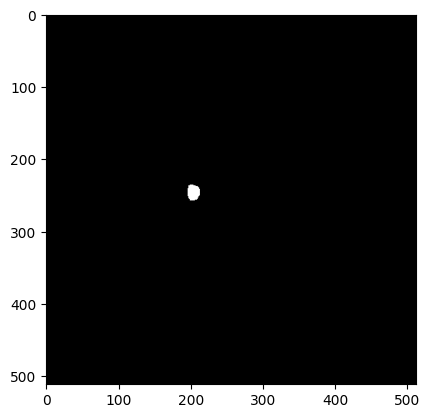

In [ ]:
#show overlay images

img_array_neoplasm = sitk.GetArrayFromImage(neoplasm_segment_img)
print(img_array_neoplasm.shape)
#print(len(input_dcm_new))

#plt.imshow(slice, cmap='gray') # overlay the original image with the segmentation mask
plt.imshow(img_array_neoplasm[60], cmap='gray') # alpha=0.2 # overlay the segmentation mask with the original image
plt.show()

In [50]:
i = 0
for _, row in path_df.iterrows():
    ct_path = Path(row['path_ct'])
    seg_path = Path(row['path_mask'])
    if i > 0:
        break
    sitk_dcms, result_seg = read_scans(ct_path, seg_path)
    i += 1

ImageSeriesReader (0x56496aaf8130): Non uniform sampling or missing slices detected,  maximum nonuniformity:2.97619



In [ ]:
print(seg.Modality)
print(seg.SOPClassUID)
print(type(seg_reader.read(seg)))

In [ ]:
#show overlay images

neoplasm_segment = result.segment_data(1) # this is the neoplasm segment, but is this always the case?
print(neoplasm_segment.shape)
neoplasm_segment_img = result.segment_image(1) # or should I do this..?
img_array_neoplasm = sitk.GetArrayFromImage(neoplasm_segment_img)
print(img_array_neoplasm.shape)
print(len(input_dcm_new))

plt.imshow(slice, cmap='gray') # overlay the original image with the segmentation mask
plt.imshow(img_array_neoplasm[80], cmap='gray', alpha=0.2) # overlay the segmentation mask with the original image
plt.show()

In [ ]:
#find neoplasm label

for seg_num, info in seg_infos.items():

    #could make this more efficient by stopping the loop if the correct item was found?
    if 'Neoplasm' not in info.get('SegmentLabel', ''):
            continue
    neo_seg_num = seg_num
    neoplasm_segment_img = result_seg.segment_image(neo_seg_num)
